In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
from scipy.optimize import minimize
from scipy.stats import norm
from numpy.fft import fft
from numpy import sqrt, exp, pi, cos, sin, log, abs
from scipy.stats import  qmc
from tqdm import tqdm, trange
from joblib import Parallel, delayed, parallel_backend
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from numba import njit
from functools import partial
from scipy import integrate
import timeit

In [2]:
#######-------------------------------------------------------------------##############
#  Problem Parameters
#
#######-------------------------------------------------------------------##############
Nv = 2000        # Number of volatility trajectories
Ns = 1000        # Number of stock price trajectories per volatility path
N_path= 100000   # simulations for the QEsim
S0 = 1          # Initial stock price
v0 = 0.0475     # Initial variance
r = 0.01        # Risk-free rate
T = 1.13        # Maturity in years
M=252           # time steps in 1y
N = int(M*T)    # Number of time steps till maturity
kappa = 7.7648  # Mean reversion speed
theta = 0.0601  # Long-run variance
sigma = 2.017   # Volatility of volatility
rho = -0.6952   # Correlation
K=1.03          #strike of the option
q=0             #no dividend
dt = 1 / M      #time step

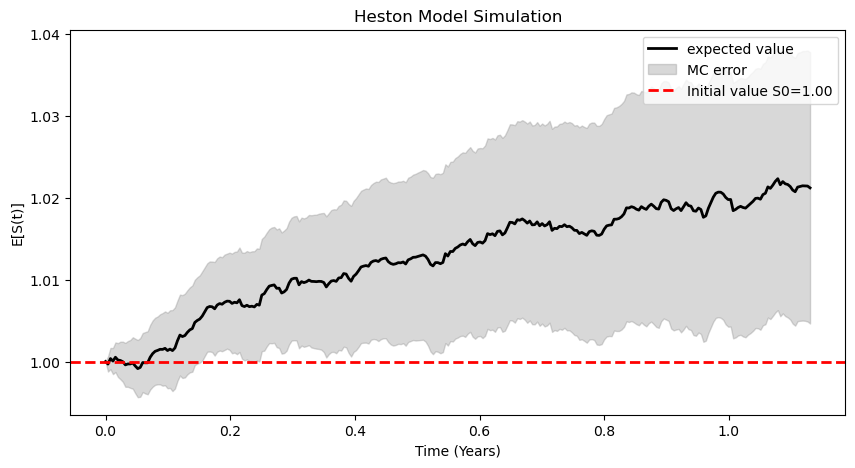

In [3]:
def simulate_heston(Nv, Ns, S0, v0, r, T, N, kappa, theta, sigma, rho):

    '''
    T=time horizon in year
    N=numbers of time step
    Nv=simulations for the volatility
    Ns=simulations for the underlying
    '''
    
    dt = T / N  # Time step
    S = np.zeros((Nv, Ns, N + 1))
    v = np.zeros((Nv, N + 1))

    S[:, :, 0] = S0
    v[:, 0] = v0

    m=np.zeros((Nv,N+1)) #matrix of mj=1/Ns sum(S)

    rand = np.random.RandomState(seed=13)

    for i in range(Nv):  # Loop over volatility trajectories
        Z_Y = rand.normal(loc=0.0, scale=1.0, size=(N,))
        for t in range(1, N + 1):
            v_hat = v[i, t - 1] + kappa * (theta - v[i, t - 1]) * dt + sigma * np.sqrt(v[i, t - 1]) * np.sqrt(dt) * Z_Y[t - 1]
            v[i, t] = max(v_hat, 0)  # Ensure non-negativity (we need to do it because Feller Condition is violeted)

        for j in range(Ns):  # Loop over stock price trajectories per volatility path
            Z_Z = rand.normal(loc=0.0, scale=1.0, size=(N,))
            for t in range(1, N + 1):
                Z = rho * Z_Y[t - 1] + np.sqrt(1 - rho**2) * Z_Z[t - 1]
                S[i, j, t] = S[i, j, t - 1] * np.exp((r - 0.5 * v[i, t - 1]) * dt + np.sqrt(v[i, t - 1]) * np.sqrt(dt) * Z)

        m[i]=np.mean(S[i],axis=0)

    exp_val_t=np.mean(m,axis=0)
    square=np.mean(m*m,axis=0)
    errors=3*np.sqrt((square-exp_val_t*exp_val_t)/Nv)

    return S, v, exp_val_t, errors



# Run simulation
S, v, m, mc_errors = simulate_heston(1000, 100, S0, v0, r, T, N, kappa, theta, sigma, rho)

# Plot simulation results: E[S] +/- error
time = np.linspace(0, T, N+1) #time grid

plt.figure(figsize=(10, 5))
plt.plot(time, m, color='black', label='expected value', linewidth=2)
plt.fill_between(time, m - mc_errors, m + mc_errors, color='gray', alpha=0.3, label='MC error')
plt.axhline(y=S0, color='red', linestyle='--', linewidth=2, label=f'Initial value S0={S0:.2f}')  # Add reference line
plt.xlabel('Time (Years)')
plt.ylabel('E[S(t)]')
plt.title('Heston Model Simulation')
plt.legend()
plt.show()

In [4]:
#######-------------------------------------------------------------------##############
#  We compute the Feller condition: is it respected?
#
#######-------------------------------------------------------------------##############
feller= (sigma**2)/(2*kappa*theta)
print(f"The feller conditon is : {feller:.4f}")
if feller >= 1:
    print("Feller condition is not respected, the process could reach 0.")
else:
    print("Feller condition is accepted")

The feller conditon is : 4.3589
Feller condition is not respected, the process could reach 0.


In [5]:
#######-------------------------------------------------------------------##############
#  We define a function to easilly compute mean and std
#
#######-------------------------------------------------------------------##############
def stats(x, axis=None):
    """
    Given the constant array 'x', stats will return the tuple
    ( E[x], StDev(x) := sqrt( E[ (x - E[x])^2 ] )), where E represents the sample average.
    """
    return x.mean(axis=axis), x.std(axis=axis)


#######-------------------------------------------------------------------##############
#  Variance for a Cir with Feller condition violated
#  It follow the QE scheme defined by Andersen
#######-------------------------------------------------------------------##############
def simulate_variance_qe(v0, kappa, theta, sigma, T, dt, NV):
    """
    Simulate variance paths using the Quadratic Exponential (QE) scheme and compute the integral (I).
    """
    M = int(T / dt)  # Number of time steps
    v = np.full((M + 1, NV), v0)  # Initialize variance matrix
    In = np.zeros((M + 1, NV))  # Initialize integral matrix (same shape as v)

    np.random.seed(42) #seed for CIR process

    for t in range(M):
        h = 1 - np.exp(-kappa * dt)
        m = theta + (v[t] - theta) * (1 - h)
        s2 = (sigma * sigma * h / kappa) * (v[t] * (1 - h) + 0.5 * theta * h)
        psi = s2 / (m ** 2)

        # For psi <= 1.5 (same logic as original)
        idx = psi <= 1.5
        b = np.sqrt(2 / psi[idx] - 1 + np.sqrt(2 / psi[idx] * (2 / psi[idx] - 1)))
        a = m[idx] / (1 + b ** 2)

        if np.any(idx):
            v[t + 1, idx] = a * (np.random.randn(np.sum(idx)) + b) ** 2

        # For psi > 1.5
        idx2 = ~idx
        if np.any(idx2):
            p = (psi[idx2] - 1) / (psi[idx2] + 1)
            beta = (1 - p) / m[idx2]
            u = np.random.rand(np.sum(idx2))
            idx3 = (u <= p)
            v[t + 1, idx2] = np.where(idx3, 0, np.log((1 - p) / (1 - u)) / beta)

        # Ensure variance is non-negative
        v[t + 1] = np.maximum(v[t + 1], 0)

        # Update integral (In) at each time step
        In[t + 1] = In[t] + (dt / 2) * (v[t] + v[t + 1])

    return v, In


#######-------------------------------------------------------------------##############
#  Algorith for the heston model: see section 14.1 lecture notes
#
#######-------------------------------------------------------------------##############

def mc_heston(rand, So, vol, intVol, kappa, theta, sigma, rho, Dt, Ns):
    L = len(intVol)  # Number of time steps
    th = theta
    k = kappa
    eta = sigma
    nu = vol
    I = intVol

    # Correct initialization of S
    S = np.zeros((L, Ns), dtype=np.double)

    xi = rand.normal(loc=0.0, scale=1.0, size=(L - 1, Ns))

    # Initialize first row of S
    S[0, :] = So

    for n in range(1, L):
        DI = I[n] - I[n - 1]
        X = -0.5 * DI + (rho / eta) * (nu[n] - nu[n - 1] - k * (th * Dt - DI)) + np.sqrt(
            (1 - rho * rho) * DI) * xi[n - 1, :]
        S[n, :] = S[n - 1, :] * np.exp(X)

    return S


#######-------------------------------------------------------------------##############
#  we unify the two algorith in order to obtain the final trajectories
#  We compute Ns trajectories for each Nv trajector
#######-------------------------------------------------------------------##############

def heston_trj(rand, So, vol, Ivol, lmbda, eta, nubar, rho, N, dt, NV, NS):
    S = np.zeros((NV, N + 1, NS), dtype=np.float64)  # Correct shape

    Ivol = Ivol.transpose()
    vol = vol.transpose()

    for nb in range(NV):
        s = mc_heston(rand, So, vol[nb], Ivol[nb], lmbda, nubar, eta, rho, dt, NS)
        S[nb] = s

    return S

In [6]:
#######-------------------------------------------------------------------##############
#  we check for the martigale property of the stock evolutions
#  We shoe the numerical results and a visualization through the plot
#######-------------------------------------------------------------------##############
def martingale_property(S0,S):

    print("%9s    %8s   %8s    %8s       %8s" % ("t", "E[S(t)]", "|S(0)-E[S(t)]|", "MC-err", "Martingality"))

    E_values = []

    Rand = np.random.RandomState()
    Rand.seed(13)

    Nv, Nt, Ns = S.shape

    m_c = np.zeros((Nt, Nv))
    s_c = np.zeros((Nt, Nv))
    E = np.zeros((Nt, 1))
    std = np.zeros((Nt, 1))

    for j, i in enumerate(range(Nt)):
        for nv in range(Nv):
            m_c[j][nv], s_c[j][nv] = stats(S[nv][i][:])

        E[j], std[j] = stats(m_c[j])
        Err = 3 * std[j] / sqrt(Nv)

        print("%9d    %8.6f      %8.2e        %8.2e      %8s" % (i, E[j][0], abs(S0 - E[j][0]), Err, Err>= abs(S0-E[j][0])))


        E_values.append(E[j][0])


    # Convert lists to numpy arrays
    times = np.arange(Nt)  # X-axis (time steps)
    E_values = np.array(E_values)  # Expected values

    # Compute confidence intervals
    confidence_intervals_upper = E_values + 3 * std.flatten() / sqrt(Nv)
    confidence_intervals_lower = E_values - 3 * std.flatten() / sqrt(Nv)

    # Plot fill_between instead of plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axhline(y=S0, color='red', linestyle='-', linewidth=1)
    ax.fill_between(times, confidence_intervals_lower, confidence_intervals_upper, color='lightblue', alpha=0.4)
    ax.plot(times, E_values, color='black', linestyle='-', linewidth=0.5)  # Keep mean line


    ax.set_xlabel('t (Days)')
    ax.set_ylabel('E[S(t)]')
    ax.set_title(f'Martingality test (NV = {Nv}, NS = {Ns})')
    ax.grid(False)
    plt.show()


        t     E[S(t)]   |S(0)-E[S(t)]|      MC-err       Martingality
        0    1.000000      0.00e+00        0.00e+00       [ True]


C:\Users\Utente\AppData\Local\Temp\ipykernel_8460\45279327.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("%9d    %8.6f      %8.2e        %8.2e      %8s" % (i, E[j][0], abs(S0 - E[j][0]), Err, Err>= abs(S0-E[j][0])))


        1    0.999604      3.96e-04        6.44e-04       [ True]
        2    0.999686      3.14e-04        9.17e-04       [ True]
        3    1.000158      1.58e-04        1.07e-03       [ True]
        4    1.000156      1.56e-04        1.27e-03       [ True]
        5    0.999914      8.65e-05        1.44e-03       [ True]
        6    1.000216      2.16e-04        1.53e-03       [ True]
        7    1.000387      3.87e-04        1.64e-03       [ True]
        8    1.000152      1.52e-04        1.76e-03       [ True]
        9    1.000202      2.02e-04        1.87e-03       [ True]
       10    0.999975      2.55e-05        1.96e-03       [ True]
       11    0.999773      2.27e-04        2.06e-03       [ True]
       12    0.999688      3.12e-04        2.16e-03       [ True]
       13    0.999581      4.19e-04        2.28e-03       [ True]
       14    0.999759      2.41e-04        2.34e-03       [ True]
       15    0.999721      2.79e-04        2.43e-03       [ True]
       16 

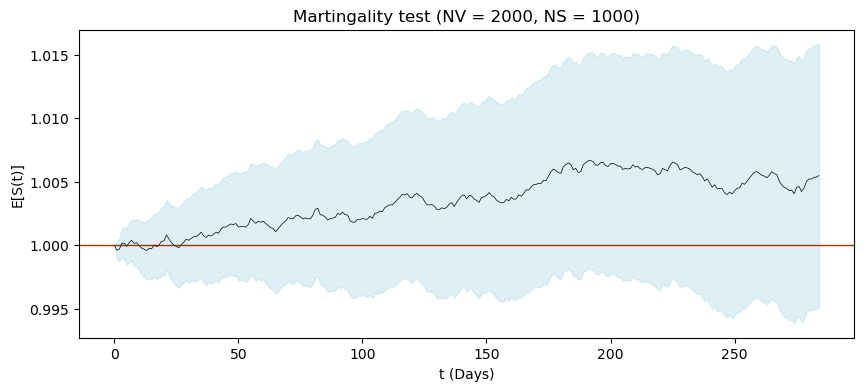

In [7]:
#######-------------------------------------------------------------------##############
#  we call the function and show the results
#  S=Matrix of all trajectoies till T=1.13 for the stock
#######-------------------------------------------------------------------##############
rand = np.random.RandomState(seed=13) #seed for Stock
vol, Ivol=simulate_variance_qe(v0, kappa, theta, sigma, T, dt, Nv)
S=heston_trj(rand, S0, vol, Ivol, kappa, sigma, theta, rho, N, dt, Nv, Ns)
#print(S.shape)
martingale_property(S0,S)

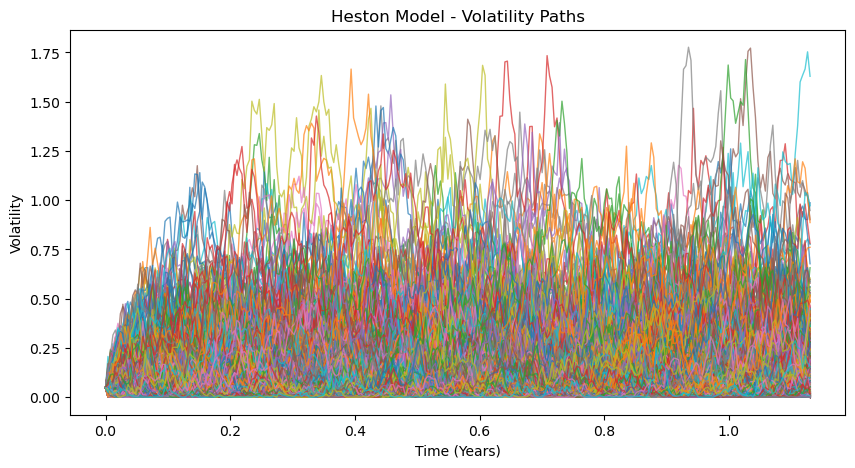

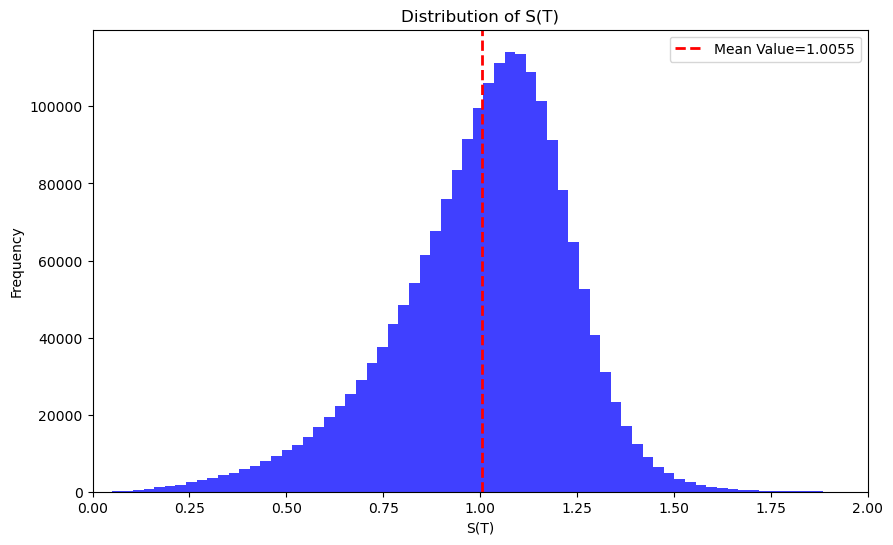

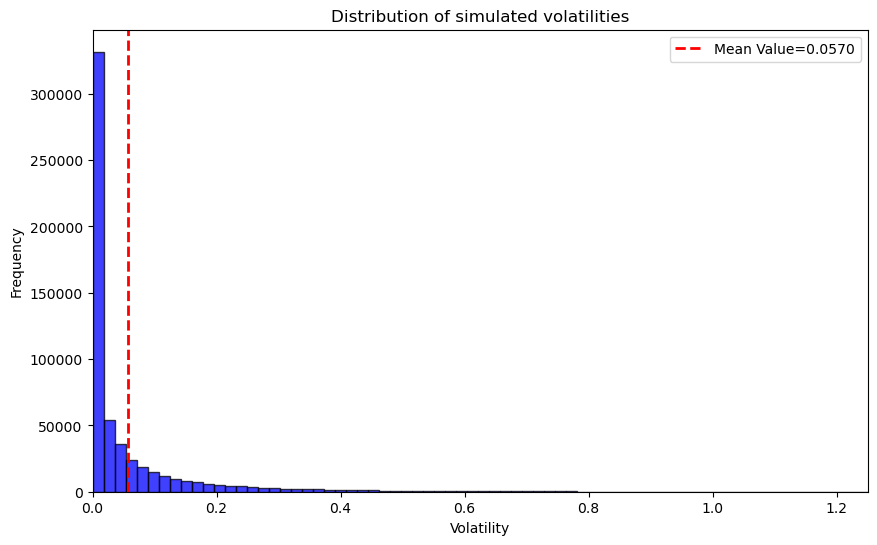

In [8]:
#######-------------------------------------------------------------------##############
#  we plot some results to visualize the model implementation
#
#######-------------------------------------------------------------------##############
#time grid
time = np.linspace(0, T, N+1)

#plot the volatility trajectories
plt.figure(figsize=(10, 5))
for i in range(Nv):
    plt.plot(time, vol[:,i], lw=1, alpha=0.7)
plt.title("Heston Model - Volatility Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Volatility")
plt.show()

#plot the stock trajectories
'''
plt.figure(figsize=(10, 5))
plt.plot(time, S.reshape(-1, S.shape[1]).T, lw=1, alpha=0.7)  # Vectorized plotting
plt.title(f"Heston Model - Stock Price Paths with seed 13 and Nv={Nv}, Ns={Ns}")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.show()
'''


#plot histrogram of S
plt.figure(figsize=(10, 6))
plt.hist(S[:,-1,:].flatten(), color='blue', bins=100, alpha=0.75)
plt.axvline(np.mean(S[:,-1,:].flatten()), color='red', linestyle='--', linewidth=2, label=f'Mean Value={np.mean(S[:,-1,:].flatten()):.4f}')  # Add reference line
plt.xlim(0,2)
plt.title('Distribution of S(T)')
plt.xlabel('S(T)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#plot the histrogram of v
plt.figure(figsize=(10, 6))
plt.hist(vol.flatten(), color="blue", edgecolor="black", bins=100, alpha=0.75)
plt.axvline(np.mean(vol.flatten()), color="red", linestyle="--", linewidth=2, label=f"Mean Value={np.mean(vol.flatten()):.4f}")  # Add reference line
plt.xlim(0,1.25)
plt.title("Distribution of simulated volatilities")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [9]:
#######-------------------------------------------------------------------##############
#  We price the Put option, by taking the pay-offs max((k-ST), 0), taking the expected value and discounting.
#  This function works only for the fixed maturity T=1.13
#######-------------------------------------------------------------------##############

def price_fixed_T(S, K, r, T):
    Nv, _, Ns= S.shape  # Get the number of simulations

    # Store payoffs for each volatility trajectory
    payoff = np.zeros(Nv)

    for i in range(Nv):
        S_T = S[i, -1, :] # Extract terminal stock prices for all Ns simulations
        #print(len(S_T))
        payoff[i] = np.mean(np.maximum(K - S_T, 0))  # Compute average (along the Ns paths)
    #print(len(payoff))

    # Compute put option payoffs
    put_payoff, std= stats(payoff) #average payoff along all the Nv paths
    # Monte Carlo estimate of option price
    put_price = np.exp(-r * T) * put_payoff
    mc_error= 3* std/np.sqrt(Nv)

    return put_price, mc_error

heston_price_put, put_error=price_fixed_T(S, K, r, T)
print(f"The Put Option Price under the Heston model (QE scheme) is: {heston_price_put:.4f}±{put_error:.4f}")

The Put Option Price under the Heston model (QE scheme) is: 0.0978±0.0081


In [10]:
#######-------------------------------------------------------------------##############
#  We price the heston process, by taking the pay-offs max((k-ST), 0), taking the expected value and discounting
#  This function works for all possible T and K
#######-------------------------------------------------------------------##############

def price_put_heston(rand, S0, kappa, sigma, theta, rho, M, T, dt, Nv, Ns, K, r):

    vol, Ivol = simulate_variance_qe(v0, kappa, theta, sigma, T, dt, Nv)
    S=heston_trj(rand, S0, vol, Ivol, kappa, sigma, theta, rho, int(M*T), dt, Nv, Ns)

    # Store payoffs for each volatility trajectory
    payoff = np.zeros(Nv)

    for i in range(Nv):
        S_T = S[i, -1, :] # Extract terminal stock prices for all Ns simulations
        #print(len(S_T))
        payoff[i] = np.mean(np.maximum(K - S_T, 0))  # Compute average (along the Ns paths)
    #print(len(payoff))

    # Compute put option payoffs
    put_payoff, std= stats(payoff) #average payoff along all the Nv paths
    # Monte Carlo estimate of option price
    put_price = np.exp(-r * T) * put_payoff
    mc_error= 3* std/np.sqrt(Nv)

    return put_price, mc_error

In [11]:
#######-------------------------------------------------------------------##############
#  Let compare the heston with small sigma to the BS with a time dependent volatility
#  
#######-------------------------------------------------------------------##############

def black_scholes_put_time_dependent(S0, K, r, v0, theta, kappa, T):
    # Compute effective volatility
    sigma_eff_squared = theta + ((v0 - theta) / (kappa * T)) * (1 - np.exp(-kappa * T))
    sigma_eff = np.sqrt(sigma_eff_squared)
    
    # Compute d1 and d2
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma_eff**2) * T) / (sigma_eff * np.sqrt(T))
    d2 = d1 - sigma_eff * np.sqrt(T)
    
    # Compute put price using Black-Scholes formula
    put_price = K * np.exp(-r * T) * si.norm.cdf(-d2) - S0 * si.norm.cdf(-d1)
    
    return put_price

nu=np.exp(-10)
heston_det, error_det=price_put_heston(rand, S0, kappa, nu, theta, rho, M, T, dt, Nv, Ns, K, r)
pr_bs_time_dep=black_scholes_put_time_dependent(S0, K, r, v0, theta, kappa, T)
print("*******************************************************************************************\n")
print(f"The Put price under Heston with sigma={nu} is: {heston_det:5f} ±{error_det:.5f}\n")
print(f"The Put price under BS with time-dependent vol is: {pr_bs_time_dep:5f}\n")
print(f"The difference between the two prices is: {abs(heston_det-pr_bs_time_dep):.5f}\n")
print(f"The difference between the two prices is smaller than the error: {abs(heston_det-pr_bs_time_dep)<error_det}\n")
print("*******************************************************************************************\n")

*******************************************************************************************

The Put price under Heston with sigma=4.5399929762484854e-05 is: 0.110171 ±0.00600

The Put price under BS with time-dependent vol is: 0.112848

The difference between the two prices is: 0.00268

The difference between the two prices is smaller than the error: True

*******************************************************************************************



In [12]:
#######-------------------------------------------------------------------##############
#  We model the Heston behaviour through the QE scheme.
#  The code is taken by the site cited 
#  FELLER CONDITION IS VIOLATED. LET IMPLEMENT A CODE THAT TAKES INTO ACCOUNT THIS FACT (QE, ANDERSEN (2008)). THE RESULTS ARE THE SAME??
#  (see: https://medium.com/@alexander.tsoskounoglou/simulating-the-heston-model-with-quadratic-exponential-50cf2b1366b5)
#######-------------------------------------------------------------------##############

def QESim(S0, V0, rho, theta, sigma, kappa, r, q, dt, T_steps, N_paths, psiC=1.5, gamma1=0.5, gamma2=0.5, Martingale_Correction=True, _show_progress=True):
    """
    Simulates the Heston model using the Quadratic Exponential (QE) scheme.

    Parameters
    ----------
    S0 : Initial stock price.
    V0 : Initial variance.
    rho : Correlation between the two Brownian motions.
    theta : Long-term mean of the variance.
    sigma : Volatility of the variance process (vol of vol).
    kappa : Rate at which variance reverts to theta.
    r : Risk-free interest rate.
    q : Dividend yield.
    dt: Time increment.
    T_steps : Number of time steps.
    N_paths : Number of simulated paths.
    psiC : float, optionaL-->Threshold parameter for the QE scheme (default is 1.5).
    gamma1 : float, optional --> Gamma parameter for the QE scheme (default is 0.5).
    gamma2 : float, optional --> Gamma parameter for the QE scheme (default is 0.5).
    Martingale_Correction : bool, optional-->If True, applies Martingale correction (default is False).
    _show_progress : bool, optional--> If True, displays progress of the simulation (default is True).

    Returns
    -------
    S : ndarray of Simulated stock prices, shape (N_paths, T_steps+1).
    V : ndarray of Simulated variances, shape (N_paths, T_steps+1).

    Notes
    -----
    The function uses Sobol sequences for generating random numbers and the inverse cumulative normal distribution to
    obtain normally distributed random variables. The QE scheme is used to handle the variance process.

    References
    ----------
    Andersen, L. (2008). Simple and efficient simulation of the Heston stochastic volatility model. Journal of Computational Finance, 11(3), 1-42.
    """
    E = np.exp(-kappa * dt)
    K0 = -(kappa * rho * theta) / sigma * dt
    K1 = (kappa * rho / sigma - 1 / 2) * gamma1 * dt - rho / sigma
    K2 = (kappa * rho / sigma - 1 / 2) * gamma2 * dt + rho / sigma
    K3 = (1 - rho ** 2) * gamma1 * dt
    K4 = (1 - rho ** 2) * gamma2 * dt 
    A = K2 + 0.5 * K4
    if Martingale_Correction: K0_star = np.empty(N_paths)

    sobol_gen = qmc.Sobol(d=T_steps + 1)
    Uv = sobol_gen.random(n=N_paths).T
    Us = sobol_gen.random(n=N_paths).T
    Zv, Zs = norm.ppf(Uv), norm.ppf(Us)

    S = np.zeros((T_steps+1, N_paths))
    V = np.zeros((T_steps+1, N_paths))

    S[0] = log(S0)
    V[0] = V0

    for t in trange(1, T_steps+1, desc="Simulating Paths", position=0, leave=False, disable=not _show_progress):
        m = theta + (V[t - 1] - theta) * E 
        s2 = (V[t - 1] * sigma**2 * E)/kappa * (1 - E) + (theta * sigma**2)/(2 * kappa)*(1 - E)**2
        psi = s2 / m ** 2

        idx = psi <= psiC
        # When psi <= psiC
        b = np.sqrt(2/psi[idx] - 1 + np.sqrt(2/psi[idx] * (2/psi[idx] - 1)))
        a = m[idx] / (1 + b**2)     
        V[t, idx] = a * (b + Zv[t, idx]) ** 2

        # When psi > psiC
        p = (psi[~idx] - 1) / (psi[~idx] + 1) 
        beta = (1 - p ) / m[~idx] 
        idx2 = (Uv[t, ~idx] <= p)
        V[t, ~idx] = np.where(idx2, 0, 1 / beta * np.log((1 - p) / (1 - Uv[t, ~idx])))

        if Martingale_Correction:
            K0_star[idx]  = - (A * b**2 * a) / (1 - 2 * A * a) + 0.5 * np.log(1 - 2 * A * a) - (K1 + 0.5 * K3) * V[t-1, idx]
            K0_star[~idx] = - np.log(p + (beta * (1 - p)) / (beta - A)) - (K1 + 0.5 * K3) * V[t-1, ~idx]

            S[t] = S[t - 1] + (r - q)*dt + K0_star + K1*V[t - 1] + K2*V[t] + np.sqrt(K3*V[t - 1] + K4*V[t])*Zs[t]
        else:
            S[t] = S[t - 1] + (r - q)*dt + K0      + K1*V[t - 1] + K2*V[t] + np.sqrt(K3*V[t - 1] + K4*V[t])*Zs[t]
    
    S = exp(S).T
    V = V.T

    # Find if there are NaN values and replace those paths with S0
    idx = np.isnan(S).sum(axis=1) == 0
    if idx.sum() < N_paths :
        print(f"Warning: {N_paths - idx.sum()} paths removed due to NaN values and replaced with E[S_t] and E[V_t]")
        S[~idx] = S0*exp((r-q)*np.arange(T_steps+1)*dt)
        V[~idx] = V0 * np.exp(-kappa * np.arange(T_steps+1)*dt) + theta * (1 - np.exp(-kappa * np.arange(T_steps+1)*dt))


    return S, V


#######-------------------------------------------------------------------##############
#  We price the put option when the imput S is a 2D matrix (as in the QE model)
#  
#######-------------------------------------------------------------------##############

def price_put_heston_qe(S, K, r, T):
    S_T = S[ :, -1]  # Get stock prices at maturity
    
    # Compute put option payoffs
    put_payoff = np.maximum(K - S_T, 0)  
    
    # Monte Carlo estimate of option price
    put_price = np.exp(-r * T) * np.mean(put_payoff)


    # Compute standard deviation of discounted payoffs
    square = np.mean(put_payoff*put_payoff)
    error= 3*np.sqrt((square-np.mean(put_payoff)*np.mean(put_payoff))/N_path)
    
    return put_price , error


#######-------------------------------------------------------------------##############
#  We print the result and later we compare itwith the one with the Euler Scheme 
#  
#######-------------------------------------------------------------------##############

#let find the QE simulations
Sqe,Vqe=QESim(S0, v0, rho, theta, sigma, kappa, r, q, dt, N, N_path, psiC=1.5, gamma1=0.5, gamma2=0.5, Martingale_Correction=False)
#let find the put price under QE simulations
heston_price_put_qe, err_qe=price_put_heston_qe(Sqe, K, r, T)
print("*******************************************************************************************\n")
print(f"The Put Option Price under the Heston model with different QE scheme, is: {heston_price_put_qe:.5f}± {err_qe:.5f}\n")
print(f"The Put price under our Heston model is: {heston_price_put:5f} ±{put_error:.5f}\n")
print(f"The difference between the two prices is: {abs(heston_price_put-heston_price_put_qe):.5f}\n")
print(f"The difference between the two prices is smaller than the error: {abs(heston_price_put-heston_price_put_qe)<put_error}\n")
print("*******************************************************************************************\n")

C:\Users\Utente\anaconda3\Lib\site-packages\scipy\stats\_qmc.py:804: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


*******************************************************************************************

The Put Option Price under the Heston model with different QE scheme, is: 0.09624± 0.00150

The Put price under our Heston model is: 0.097819 ±0.00808

The difference between the two prices is: 0.00158

The difference between the two prices is smaller than the error: True

*******************************************************************************************



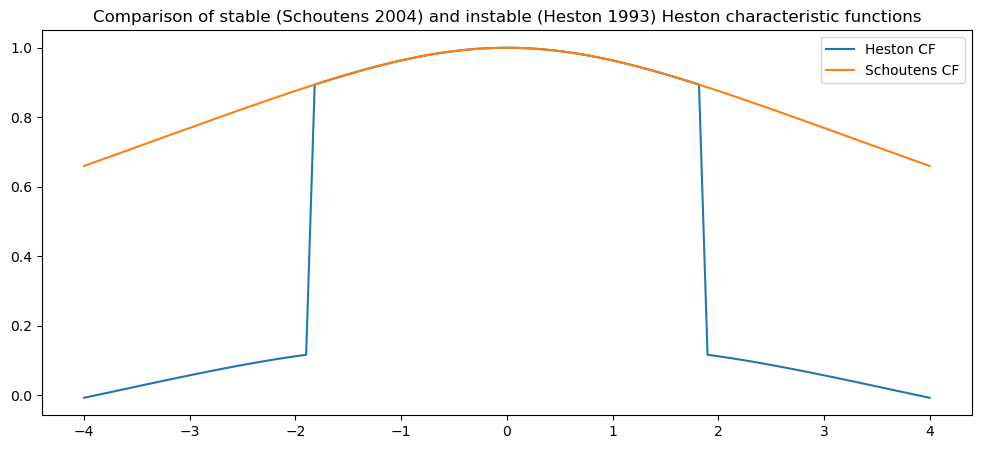

In [13]:
#######-------------------------------------------------------------------##############
#  We develop a code to compute the Price using the Fourier Transform
#  Firstly, we start computing the characteristic function
#######-------------------------------------------------------------------##############

parameters = {
    "lambda" : 7.7648,  #kappa
    "v_bar": 0.0601,   #theta
    "eta": 2.017,     #sigma
    "v_0": 0.0475,
    "rho": -0.6952,
    "ir" : 0.01,
    "seed": 42,
    "S0" : 1,
    "N" : 10000,
    "T": 1.13,
    "dt": 1/252,
    "alpha": 1.5,
    "K": 1.03
}
#######------------------------------########
#   Characteristic proposed by HEston 1993
#   #sigma=lambda
#######------------------------------########
def cf_Heston_unstable(u, t, v0, mu, kappa, theta, sigma, rho):

    xi = kappa - sigma * rho * u * 1j
    d = np.sqrt(xi**2 + sigma**2 * (u**2 + 1j * u))
    g1 = (xi + d) / (xi - d)
    cf = np.exp(
        1j * u * mu * t
        + (kappa * theta) / (sigma**2) * ((xi + d) * t - 2 * np.log((1 - g1 * np.exp(d * t)) / (1 - g1)))
        + (v0 / sigma**2) * (xi + d) * (1 - np.exp(d * t)) / (1 - g1 * np.exp(d * t))
    )
    return cf

#######------------------------------########
#   Characteristic proposed by Schoutens 2004
#   #sigma=lambda
#######------------------------------########
def cf_Heston_stable(u, t, v0, mu, kappa, theta, sigma, rho):

    xi = kappa - sigma * rho * u * 1j
    d = np.sqrt(xi**2 + sigma**2 * (u**2 + 1j * u))
    g1 = (xi + d) / (xi - d)
    g2 = 1 / g1
    cf = np.exp(
        1j * u * mu * t
        + (kappa * theta) / (sigma**2) * ((xi - d) * t - 2 * np.log((1 - g2 * np.exp(-d * t)) / (1 - g2)))
        + (v0 / sigma**2) * (xi - d) * (1 - np.exp(-d * t)) / (1 - g2 * np.exp(-d * t))
    )
    return cf

#######------------------------------########
# Implementation :
#https://github.com/cantaro86/Financial-Models-Numerical-Methods/blob/585ed19462665bd822c88b5b6e34fca8ad441370/1.4%20SDE%20-%20Heston%20model.ipynb
#######------------------------------########
cf_H_b = partial(cf_Heston_unstable, t=parameters["T"], v0=parameters["v_0"], mu=parameters["ir"], theta=parameters["v_bar"], sigma=parameters["eta"], kappa=parameters["lambda"], rho=parameters["rho"])
cf_H_b_good = partial(cf_Heston_stable, t=parameters["T"], v0=parameters["v_0"], mu=parameters["ir"], theta=parameters["v_bar"], sigma=parameters["eta"], kappa=parameters["lambda"], rho=parameters["rho"])



u = np.linspace(-4, 4, 100)

plt.figure(figsize=(12, 5))
plt.plot(u, np.real(cf_H_b(u)), label="Heston CF")
plt.plot(u, np.real(cf_H_b_good(u)), label="Schoutens CF")
plt.title("Comparison of stable (Schoutens 2004) and instable (Heston 1993) Heston characteristic functions")
plt.legend()
plt.show()

In [14]:
#######------------------------------########
# We set our benchmark as the continous version of the Fourier transform to price the Put.
#
# Precise but computationally expensive, particularly with a lot of options
# (but we need to compute just one option)
#######------------------------------########

def psi_T_heston(r, T, v, alpha, v0, mu, kappa, theta, sigma, rho):
    num = np.exp(-r * T) * cf_Heston_stable(v - (alpha + 1) * 1j, T, v0, mu, kappa, theta, sigma, rho)
    den = (alpha**2) + alpha - v**2 + 1j * (2 * alpha + 1) * v
    return num / den

def integral_value_heston(alpha, S0, K, r, T, v0, mu, kappa, theta, sigma, rho):
    k = np.log(K / S0)
    a = np.exp(-alpha * k) / np.pi

    def integrand(v):
        return np.exp(-1j * v * k) * psi_T_heston(r, T, v, alpha, v0, mu, kappa, theta, sigma, rho)

    b, _ = integrate.quad(lambda v: np.real(integrand(v)), 0, np.inf)
    return S0 * a * b

def put_from_call(call_price, S, K, r, T):
    return call_price - S + K * np.exp(-r * T)

call_fourier_heston = integral_value_heston(parameters["alpha"], parameters["S0"], parameters["K"], parameters["ir"], parameters["T"], parameters["v_0"], parameters["ir"], parameters["lambda"], parameters["v_bar"], parameters["eta"], parameters["rho"])
put_fourier_integral_heston = put_from_call(call_fourier_heston, parameters["S0"], parameters["K"], parameters["ir"], parameters["T"])

print("*******************************************************************************************\n")
print(f"Fourier-based Benchmark (integral transform) Heston Put Price: {put_fourier_integral_heston:.5f}\n")
print(f"Price obtained via MC with QE scheme: {heston_price_put:.5f} ± {put_error:.5f}\n")
print(f"Price difference: {abs(put_fourier_integral_heston-heston_price_put):.5f}\n")
print(f"The Benchmark intragral is in our interval of prices: {bool(abs(put_fourier_integral_heston-heston_price_put)<=put_error):}\n")
print("*******************************************************************************************\n")

*******************************************************************************************

Fourier-based Benchmark (integral transform) Heston Put Price: 0.09754

Price obtained via MC with QE scheme: 0.09782 ± 0.00808

Price difference: 0.00028

The Benchmark intragral is in our interval of prices: True

*******************************************************************************************



In [15]:
#######------------------------------########
# Discrete method for pricing:
# COS method
#https://medium.com/@alexander.tsoskounoglou/pricing-options-with-fourier-series-p3-the-heston-model-d157369a217a
#######------------------------------########

def Fourier_Heston_Put_COS_method(S0, K, T, r, kappa, theta, rho, sigma, v0, opt_type, N=1_012, z=24):

    def heston_char(u):
        mu = parameters["ir"]
        return cf_Heston_stable(u, T, v0, mu, kappa, theta, sigma, rho)

    c1 = log(S0) + r * T - 0.5 * theta * T
    c2 = (theta / (8 * kappa**3)) * (-sigma**2 * exp(-2 * kappa * T) + 4 * sigma * exp(-kappa * T) * (sigma - 2 * kappa * rho) + 2 * kappa * T * (4 * kappa**2 + sigma**2 - 4 * kappa * sigma * rho) + sigma * (8 * kappa * rho - 3 * sigma))

    a = c1 - z * sqrt(abs(c2))
    b = c1 + z * sqrt(abs(c2))

    h = lambda n: (n * pi) / (b - a)

    g_n = lambda n: ((exp(a) - (K / h(n)) * sin(h(n) * (a - log(K))) - K * cos(h(n) * (a - log(K)))) / (1 + h(n)**2))

    g0 = K * (log(K) - a - 1) + exp(a)

    F = g0

    for n in range(1, N + 1):
        h_n = h(n)
        char_val = heston_char(h_n)
        integrand = 2 * char_val * exp(-1j * h_n * a) * g_n(n)
        F += integrand.real

    F = exp(-r * T) / (b - a) * F

    if opt_type == 'p':
        return max(F, 0)
    else:
        return max(F + S0 - K * exp(-r * T), 0)



price_put_cos = Fourier_Heston_Put_COS_method(parameters["S0"], parameters["K"], parameters["T"], parameters["ir"], parameters["lambda"], parameters["v_bar"], parameters["rho"], parameters["eta"], parameters["v_0"], 'p', N=1_012, z=24)
print("*********************************************************************\n")
print(f"Put Price obtained with COS method: {price_put_cos:.5f}\n")
print(f"Put price obtained via MC with QE scheme: {heston_price_put:.5f} ± {put_error:.5f}\n")
print(f"Price difference: {abs(price_put_cos-heston_price_put):.5f}\n")
print(f"The COS method price is in our interval of prices: {bool(abs(price_put_cos-heston_price_put)<=put_error):}\n")
print("*********************************************************************\n")

*********************************************************************

Put Price obtained with COS method: 0.09754

Put price obtained via MC with QE scheme: 0.09782 ± 0.00808

Price difference: 0.00028

The COS method price is in our interval of prices: True

*********************************************************************



In [16]:
#######------------------------------########
# Discrete method for pricing:
#
# Carr & Madan Adapted from: https://github.com/BrownianNotion/OptionFFT/blob/master/optionfft.py
#######------------------------------########

def MCallFTo(r, T, v, alpha, v0, mu, kappa, theta, sigma, rho):
    """Compute the Fourier transform of the modified call option using the Heston model.

    Parameters
    ----------
    r : float
        Risk-free interest rate.

    T : float
        Time to maturity of the call option.

    v : float
        Value at which to compute the Fourier Transform.

    alpha : float
        The modification parameter used in defining the modified call.

    v0 : float
        Initial variance.

    mu : float
        Drift term of the variance process.

    kappa : float
        Rate of mean reversion.

    theta : float
        Long-term variance mean.

    sigma : float
        Volatility of variance.

    rho : float
        Correlation between asset returns and variance.

    Returns
    -------
    Psi : float
        The Fourier transform, Psi_{T}(v), of the modified call price
        c_{T}(k) = e^{alpha*k}*C_{T}(k),
        evaluated at v.
    """
    denom = (alpha**2) + alpha - v**2 + 1j * (2 * alpha + 1) * v
    num = np.exp(-r * T) * cf_Heston_stable(v - (alpha + 1) * 1j, T, v0, mu, kappa, theta, sigma, rho)

    return num / denom


def logStrikePartition(eta = 0.25, N = 4096):
    """Creates a partition of strike prices in the log-space for use in the
    FFT pricing functions.

    Parameters
    ----------
    eta : float, optional
        The spacing size used in the quadrature of the modified call's Fourier
        transform. Default value is 0.25 from Carr and Madan 1999.

    N : int, optional
        The number of points used in the quadrature of the modified call's
        Fourier transform. Defaul value is 2**12 = 4096 from Carr and Madan
        1999. Note, N should be a power of 2 for ideal performance in the fft.

    Returns
    -------
    b : float
        See description of k.
    lamb : float
        See description of k.
    k : array_like(float, ndim=1)
        Numpy array with N strike prices in the log space uniformly spaced in
        the interval [-b, b). lamb is the spacing size between log-strikes
        in k.
    """
    b = np.pi/eta
    lamb = 2*np.pi/(eta*N)
    k = -b + lamb*np.arange(0, N)
    return (b, lamb, k)

def FFTPrice(r, T, v0, mu, kappa, theta, sigma, rho, L=0, U=np.inf, alpha=1.5, eta=0.25, N=4096):
    """ Computes an array of call option prices using the FFT method by Carr and Madan (1999).

    Parameters
    ----------
    r : float
        Risk-free interest rate.

    T : float
        Time to maturity.

    v0, mu, kappa, theta, sigma, rho : float
        Heston model parameters.

    L : float, optional
        Lower strike price bound.

    U : float, optional
        Upper strike price bound.

    alpha : float, optional
        Modification parameter (default 1.5).

    eta : float, optional
        Integration step size (default 0.25).

    N : int, optional
        Number of FFT points (default 4096).

    Returns
    -------
    callPrices : ndarray
        Call option prices for strikes between L and U.
    """
    # Integration grid
    V = np.arange(0, N * eta, eta)  # Frequencies

    # Log-strike partition
    b, lamb, k = logStrikePartition(eta, N)

    # Simpson's rule weights for integration
    pm_one = np.empty(N)
    pm_one[::2] = -1
    pm_one[1::2] = 1
    Weights = 3 + pm_one
    Weights[0] -= 1  # First weight adjustment
    Weights = (eta / 3) * Weights

    # Compute Fourier transform of modified call price
    psi_values = np.array([
        MCallFTo(r, T, v, alpha, v0, mu, kappa, theta, sigma, rho) for v in V
    ])

    x = np.exp(1j * b * V) * psi_values * Weights
    callPrices = np.real((np.exp(-alpha * k) / np.pi) * fft(x))

    # Filter for strikes within [L, U]
    strikes = np.exp(k)
    valid_indices = np.logical_and(strikes > L, strikes < U)

    return strikes[valid_indices], callPrices[valid_indices]

strikes_carr, call_prices_carr = FFTPrice(r=parameters["ir"], T=parameters["T"], v0=parameters["v_0"],
                              mu=0.0, kappa=parameters["lambda"], theta=parameters["v_bar"],
                              sigma=parameters["eta"], rho=parameters["rho"], alpha=parameters["alpha"], eta=0.25, N=4096)



strike_index = np.argmin(np.abs(strikes_carr - parameters["K"])) #find the index where the distance between K and the strike price grid is minimized


put_price_fft_carr = put_from_call(call_prices_carr[strike_index], parameters["S0"], parameters["K"], parameters["ir"], parameters["T"])


print("*********************************************************************\n")
print(f"Put Price obtained with Carr & Madan method: {put_price_fft_carr:.5f}\n")
print(f"Put price obtained via MC with QEscheme: {heston_price_put:.5f} ± {put_error:.5f}\n")
print(f"Price difference: {abs(put_price_fft_carr-heston_price_put):.5f}\n")
print(f"The FFT method price is in our interval of prices: {bool(abs(put_price_fft_carr-heston_price_put)<=put_error):}\n")
print("*********************************************************************\n")

*********************************************************************

Put Price obtained with Carr & Madan method: 0.09025

Put price obtained via MC with QEscheme: 0.09782 ± 0.00808

Price difference: 0.00757

The FFT method price is in our interval of prices: True

*********************************************************************



In [17]:
#######------------------------------########
# We dispaly the comparison between the models.
# We compare each model to the Heston. 
#Are the model results equal to the heston result??
#######------------------------------########

methods = {
    "Our Heston Model": heston_price_put,
    "Different QE Scheme": heston_price_put_qe,
    "Integral Fourier" : put_fourier_integral_heston,
    "Carr & Madan FFT": put_price_fft_carr,
    "COS Method": price_put_cos,
}

data = []
for name, price in methods.items():
    abs_diff = abs(price - heston_price_put)
    rel_error = (abs_diff / heston_price_put) * 100
    accettable= abs(price-heston_price_put)<=put_error
    data.append([name, price, abs_diff, rel_error,accettable])

df_errors = pd.DataFrame(data, columns=["Method", "Put Price", "Absolute Difference", "Relative Error (%)","Is in the Price Interval"])

df_errors

,Method,Put Price,Absolute Difference,Relative Error (%),Is in the Price Interval
0,Our Heston Model,0.097819,0.000000,0.000000,True
1,Different QE Scheme,0.096237,0.001583,1.618003,True
2,Integral Fourier,0.097539,0.000280,0.286433,True
3,Carr & Madan FFT,0.090246,0.007573,7.742053,True
4,COS Method,0.097539,0.000280,0.286433,True


In [18]:
#######------------------------------########
# Computational time comparison
#
#######------------------------------########
execution_times = {
     "Our Heston Model": timeit.timeit(
        lambda: heston_trj(
            rand, S0, vol, Ivol, kappa, sigma, theta, rho, N, dt, Nv, Ns
        ), number=1
    ),
     "Different QE Scheme": timeit.timeit(
        lambda: QESim(S0, v0, rho, theta, sigma, kappa, r, q, dt, N, N_path, psiC=1.5, gamma1=0.5, gamma2=0.5, Martingale_Correction=False
        ), number=1
    ),
    "Integral Fourier": timeit.timeit(
        lambda: integral_value_heston(
            parameters["alpha"], parameters["S0"], parameters["K"], parameters["ir"],
            parameters["T"], parameters["v_0"], parameters["ir"], parameters["lambda"],
            parameters["v_bar"], parameters["eta"], parameters["rho"]
        ), number=1
    ),
    "COS Method": timeit.timeit(
        lambda: Fourier_Heston_Put_COS_method(
            parameters["S0"], parameters["K"], parameters["T"], parameters["ir"],
            parameters["lambda"], parameters["v_bar"], parameters["rho"],
            parameters["eta"], parameters["v_0"], 'p', N=1_012, z=24
        ), number=1
    ),
    "Carr & Madan FFT": timeit.timeit(
        lambda: FFTPrice(
            r=parameters["ir"], T=parameters["T"], v0=parameters["v_0"],
            mu=0.0, kappa=parameters["lambda"], theta=parameters["v_bar"],
            sigma=parameters["eta"], rho=parameters["rho"], alpha=parameters["alpha"],
            eta=0.25, N=4096
        ), number=1
    )
}

C:\Users\Utente\anaconda3\Lib\site-packages\scipy\stats\_qmc.py:804: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


In [19]:
df_time = pd.DataFrame(list(execution_times.items()), columns=["Method", "Execution Time (s)"])
df_time = df_time.sort_values(by="Execution Time (s)", ascending=False)


df_merged = df_errors.merge(df_time, on="Method", how="inner")
df_merged_sorted = df_merged.sort_values(by=["Execution Time (s)"])
df_merged_sorted


,Method,Put Price,Absolute Difference,Relative Error (%),Is in the Price Interval,Execution Time (s)
2,Integral Fourier,0.097539,0.000280,0.286433,True,0.004622
4,COS Method,0.097539,0.000280,0.286433,True,0.031792
3,Carr & Madan FFT,0.090246,0.007573,7.742053,True,0.098722
1,Different QE Scheme,0.096237,0.001583,1.618003,True,17.950890
0,Our Heston Model,0.097819,0.000000,0.000000,True,38.599062


In [20]:
#######-------------------------------------------------------------------##############
#   We create the fucntion to price the option with the BS formula
#
#######-------------------------------------------------------------------##############
sigbs = 0.25

def black_scholes_put(S, Kput, Tput, r, q, sigbs):
    d1 = (np.log(S/Kput) + (r - q + sigbs**2/2)*Tput) / (sigbs * np.sqrt(Tput))
    d2 = d1 - sigbs * np.sqrt(Tput)
    put_price = Kput * np.exp(-r * Tput) * norm.cdf(-d2) - S * np.exp(-q * Tput) * norm.cdf(-d1)
    return put_price

#bs_put_price=black_scholes_put(S0, K, T, r, q, sigbs) #check wheather the function works
#print(f"The Price of the Put Option under the Black-Scholes model is: {bs_put_price:.4f}")

In [21]:
#######-------------------------------------------------------------------##############
#   We find the Implied Volatility through a standard bisection formula
#
#######-------------------------------------------------------------------##############

def implied_vol(S0,Mkt_Price, Tput, Kput, r, q, tolerance = 0.00001):
    sigma_max = 1
    sigma_min = 0.01
    sigma_center = (sigma_max + sigma_min)/2
    
    while black_scholes_put(S0, Kput, Tput, r, q, sigma_max) < Mkt_Price and sigma_max < 10:
        sigma_max = 2*sigma_max
    
    while black_scholes_put(S0, Kput, Tput, r, q, sigma_min) > Mkt_Price and sigma_min > 0.00001:
        sigma_min = 0.5*sigma_min

    max_iterations = 100
    iterations = 0
    
    while np.abs(black_scholes_put(S0, Kput, Tput, r, q, sigma_center) - Mkt_Price) > tolerance:
        if iterations > max_iterations:
            print(f"Warning: IV not converging for K={Kput}, T={Tput}")
            return np.nan  # Prevent infinite loop

        if black_scholes_put(S0, Kput, Tput, r, q, sigma_center) < Mkt_Price:
            sigma_min = sigma_center
        else:
            sigma_max = sigma_center

        sigma_center = (sigma_max + sigma_min) / 2
        iterations += 1
    
    return sigma_center

In [22]:
#######-------------------------------------------------------------------##############
# We find the implied volatility calling the above function
#
#######-------------------------------------------------------------------##############
impl_vol= implied_vol(S0,heston_price_put, T, K, r, q, tolerance = 0.00001)
print(f"The implied volatility is: {impl_vol:.5f}")

The implied volatility is: 0.20674


In [23]:
#######-------------------------------------------------------------------##############
# We check whether the BS price with implied volatility is the one we computed
#
#######-------------------------------------------------------------------##############
test_price= black_scholes_put(S0, K, T, r, q, impl_vol)
print(f"The BS price computed with the implied volatility is: {test_price:.5f}")
print(f"Difference between two prices: {abs(test_price-heston_price_put):.5f}")

The BS price computed with the implied volatility is: 0.09782
Difference between two prices: 0.00000


Price at K=0.8, T=0.25: 0.005261196211250572
0.322275390625
Price at K=0.8, T=0.5: 0.012047758590067386
0.28880004882812504
Price at K=0.8, T=0.75: 0.018401925119698466
0.2735125732421875
Price at K=0.8, T=1.0: 0.024791832794481404
0.26644287109375003
Price at K=0.8, T=1.25: 0.030651217006794164
0.261246337890625
Price at K=0.8, T=1.5: 0.03636794537560152
0.25822509765624996
Price at K=0.8, T=1.75: 0.0416189735649558
0.25550598144531256
Price at K=0.8, T=2.0: 0.04687828228989316
0.25411621093750003
Price at K=0.8, T=2.25: 0.05176323928004492
0.25275665283203125
Price at K=0.9, T=0.25: 0.013724605372482325
0.25774169921875
Price at K=0.9, T=0.5: 0.025236621166647058
0.2416082763671875
Price at K=0.9, T=0.75: 0.03494932485876738
0.23550537109375003
Price at K=0.9, T=1.0: 0.044930745375117695
0.23677429199218747
Price at K=0.9, T=1.25: 0.05342655282175405
0.23662322998046875
Price at K=0.9, T=1.5: 0.06133750984635522
0.23707641601562499
Price at K=0.9, T=1.75: 0.06822958930407418
0.236683

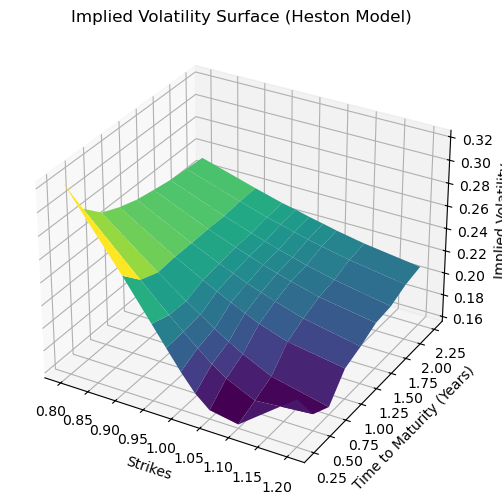

In [24]:
#######-------------------------------------------------------------------##############
# We find the implied volatility surface, by utilizing a grid of strike and Time to
# maturity
#######-------------------------------------------------------------------##############
strikes_surf = np.array([0.8, 0.9, 0.95, 0.975, 1, 1.025, 1.05, 1.1, 1.2])
T_surf = np.array([0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25])


implied_vols = np.zeros((len(strikes_surf),len(T_surf)))

for i, Ka in enumerate(strikes_surf):
    for j, Ti in enumerate(T_surf):
        new_price, _ = price_put_heston(rand, S0, kappa, sigma, theta, rho, M, Ti, dt, Nv, Ns, Ka, r)
        print(f"Price at K={Ka}, T={Ti}: {new_price}")  # Debug line
        # Minimize the difference between Black-Scholes price and Heston price
        implied_vols[i, j] = implied_vol(S0,new_price, Ti, Ka, r, q, tolerance = 0.00001)
        print(implied_vols[i, j])


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")


X, Y = np.meshgrid(strikes_surf, T_surf)
Z=implied_vols.T

ax.plot_surface(X, Y, Z, cmap="viridis")


ax.set_xlabel("Strikes")
ax.set_ylabel("Time to Maturity (Years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Implied Volatility Surface (Heston Model)")

plt.show()

#for i in range(len(T_surf)):
 # print(implied_vols[:,i])

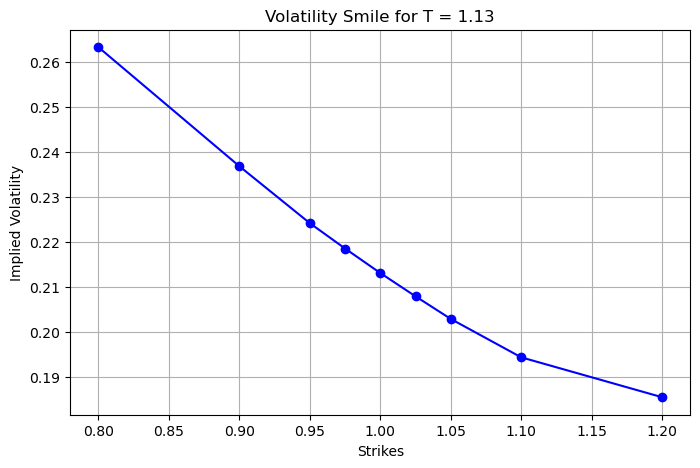

In [25]:
########-------------------------------------------------------------------##############
# we compute the implied volatility and check if the smile resemble the one
# in the volatility surface
#######-------------------------------------------------------------------##############
implied_vols = []
for Kap in strikes_surf:
    new_price, _ = price_put_heston(rand, S0, kappa, sigma, theta, rho, M, T, dt, Nv, Ns, Kap, r)

    # Minimize the squared error to find implied volatility
    result = implied_vol(S0,new_price, T, Kap, r, q, tolerance = 0.00001)

    implied_vols.append(result)  # Store implied volatility

# Convert list to numpy array
implied_vols = np.array(implied_vols)

# Plot Volatility Smile
plt.figure(figsize=(8, 5))
plt.plot(strikes_surf, implied_vols, marker="o", linestyle="-", color="b")

# Labels & Title
plt.xlabel("Strikes")
plt.ylabel("Implied Volatility")
plt.title(f"Volatility Smile for T = {T}")
plt.grid(True)

# Show plot
plt.show()


In [26]:
#######-------------------------------------------------------------------##############
#  We compare the results of the implied volatilities generated
#  by the paths of the QE scheme with the benchmarks. 
#  We check also that the Benchmark Put results are inside our price interval
#######-------------------------------------------------------------------##############
benchmark_data = []
with open("heston_benchmarks.txt", "r") as file:
    lines = file.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                T, log_K, strike, imp_vol, put_price = map(float, parts)
                benchmark_data.append([T, log_K, strike, imp_vol, put_price])
            except ValueError:
                continue  


benchmark_df = pd.DataFrame(benchmark_data, columns=["T", "log_K", "Strike", "Benchmark_IV", "Benchmark_Put"])


def compute_values(row):
    strike_test = row["Strike"]
    T_test = row["T"]

    
    res, errr = price_put_heston(rand, S0, kappa, sigma, theta, rho, M, T_test, dt, Nv, Ns, strike_test, r) 

   
    result = implied_vol(S0, res, T_test, strike_test, r, q, tolerance = 0.00001)
    
    
    IV = result
    
    return pd.Series([res, errr, IV])


benchmark_df[["Computed_Put", "Error_Put", "Computed_IV"]] = benchmark_df.apply(compute_values, axis=1)

# Check if benchmark values are within computed range ± error
benchmark_df["Put_Check"] = (
    (benchmark_df["Benchmark_Put"] >= benchmark_df["Computed_Put"] - benchmark_df["Error_Put"]) &
    (benchmark_df["Benchmark_Put"] <= benchmark_df["Computed_Put"] + benchmark_df["Error_Put"])
)


print(benchmark_df[["T", "Strike", "Benchmark_IV", "Computed_IV", "Benchmark_Put", "Computed_Put", "Error_Put", "Put_Check"]])

# Save to CSV for reference

with open("benchmark_comparison_QE.txt", "w") as f:
    f.write(benchmark_df.to_string(index=False))

         T  Strike  Benchmark_IV  Computed_IV  Benchmark_Put  Computed_Put  \
0   0.0806   0.800        0.3893     0.373516         0.0008      0.000592   
1   0.0806   0.900        0.3018     0.295205         0.0043      0.003886   
2   0.0806   0.950        0.2496     0.246140         0.0095      0.008997   
3   0.0806   0.975        0.2204     0.218345         0.0141      0.013655   
4   0.0806   1.000        0.1898     0.189341         0.0215      0.021034   
..     ...     ...           ...          ...            ...           ...   
58  2.0000   1.000        0.2180     0.223904         0.1225      0.114904   
59  2.0000   1.025        0.2144     0.221003         0.1349      0.126834   
60  2.0000   1.050        0.2109     0.217952         0.1481      0.139407   
61  2.0000   1.100        0.2042     0.212695         0.1770      0.167178   
62  2.0000   1.200        0.1923     0.205384         0.2445      0.232698   

    Error_Put  Put_Check  
0    0.000272       True  
1    0.00

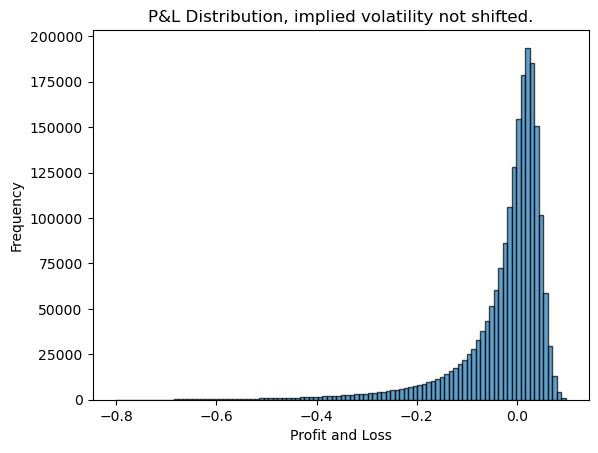

In [27]:
#######-------------------------------------------------------------------##############
# We find the PnL plot with the original implied volatility
#
#######-------------------------------------------------------------------##############
tM = 0.5

# Get all stock prices at time tM (Nv x Ns)
S_tM = S[:, 126, :]  # Shape: (Nv, Ns)

# Vectorized computation of option prices for all stock prices at time tM
option_prices_tM = black_scholes_put(S_tM, K, T - tM, r, q, impl_vol)  # Shape: (Nv, Ns)

# Ensure proper P&L calculation
PL_new = heston_price_put - np.exp(-r * tM) * option_prices_tM  # P&L calculation

# Plot histogram of P&L
plt.hist(PL_new.flatten(), bins=100, edgecolor="black", alpha=0.7)  # Flatten array
plt.xlabel("Profit and Loss")
plt.ylabel("Frequency")
plt.title("P&L Distribution, implied volatility not shifted.")
plt.show()


In [28]:
#######-------------------------------------------------------------------##############
# We find the VAR for various p and for the original and shifted volatilities
#
#######-------------------------------------------------------------------##############
VaR_10 = np.percentile(PL_new.flatten(), 90)
VaR_5 = np.percentile(PL_new.flatten(), 95)
VaR_1 = np.percentile(PL_new.flatten(), 99)

print(f"VaR without any shifting: volatility={impl_vol:.4f}")
print(f"VaR 10%: {VaR_10:.4f}")
print(f"VaR 5%: {VaR_5:.4f}")
print(f"VaR 1%: {VaR_1:.4f}\n")

VaR without any shifting: volatility=0.2067
VaR 10%: 0.0443
VaR 5%: 0.0535
VaR 1%: 0.0699



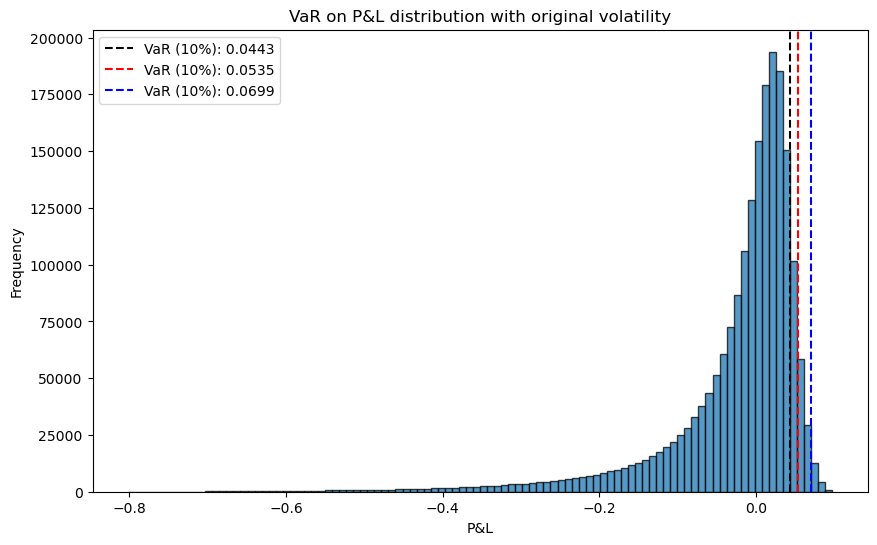

In [29]:
#######-------------------------------------------------------------------##############
# We plot the PnL with the VAR thresholds
#
#######-------------------------------------------------------------------##############
plt.figure(figsize=(10, 6))
plt.hist(PL_new.flatten(), bins=100, edgecolor="black", alpha=0.75)  # Use flattened PL
plt.axvline(VaR_10, color="black", linestyle="--", label=f"VaR (10%): {VaR_10:.4f}")
plt.axvline(VaR_5, color="red", linestyle="--", label=f"VaR (10%): {VaR_5:.4f}")
plt.axvline(VaR_1, color="blue", linestyle="--", label=f"VaR (10%): {VaR_1:.4f}")
plt.title("VaR on P&L distribution with original volatility")
plt.xlabel("P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [30]:
vol_shifts = [-0.5, -0.1, -0.05, 0.05, 0.1, 0.5]
for delta in vol_shifts:
    sigma_adj = impl_vol * (1 + delta)  # Adjusted volatility

    # Extract stock prices at time tM (Nv, Ns)
    S_tM = S[:, 126, :]  # Shape: (Nv, Ns)

    # Compute option prices using vectorized Black-Scholes for the entire S_tM at once
    option_prices_tM_adj = black_scholes_put(S_tM, K, tM, r, q, sigma_adj)  # Vectorized over Nv and Ns

    # Compute adjusted P&L (Value at Risk)
    V_adj = heston_price_put - np.exp(-r * tM) * option_prices_tM_adj

    # Compute percentiles using flattened V_adj
    VaR_adj_10 = np.percentile(V_adj.flatten(), 90)
    VaR_adj_5 = np.percentile(V_adj.flatten(), 95)
    VaR_adj_1 = np.percentile(V_adj.flatten(), 99)

    print(f"VaR for a shift of {delta:.2%}: volatility={sigma_adj:.4f}")
    print(f"VaR 10% = {VaR_adj_10:.4f} \n VaR 5% = {VaR_adj_5:.4f} \n VaR 1% = {VaR_adj_1:.4f}\n")


VaR for a shift of -50.00%: volatility=0.1034
VaR 10% = 0.0960 
 VaR 5% = 0.0972 
 VaR 1% = 0.0978

VaR for a shift of -10.00%: volatility=0.1861
VaR 10% = 0.0833 
 VaR 5% = 0.0886 
 VaR 1% = 0.0950

VaR for a shift of -5.00%: volatility=0.1964
VaR 10% = 0.0811 
 VaR 5% = 0.0868 
 VaR 1% = 0.0941

VaR for a shift of 5.00%: volatility=0.2171
VaR 10% = 0.0765 
 VaR 5% = 0.0830 
 VaR 1% = 0.0920

VaR for a shift of 10.00%: volatility=0.2274
VaR 10% = 0.0742 
 VaR 5% = 0.0810 
 VaR 1% = 0.0908

VaR for a shift of 50.00%: volatility=0.3101
VaR 10% = 0.0535 
 VaR 5% = 0.0624 
 VaR 1% = 0.0775



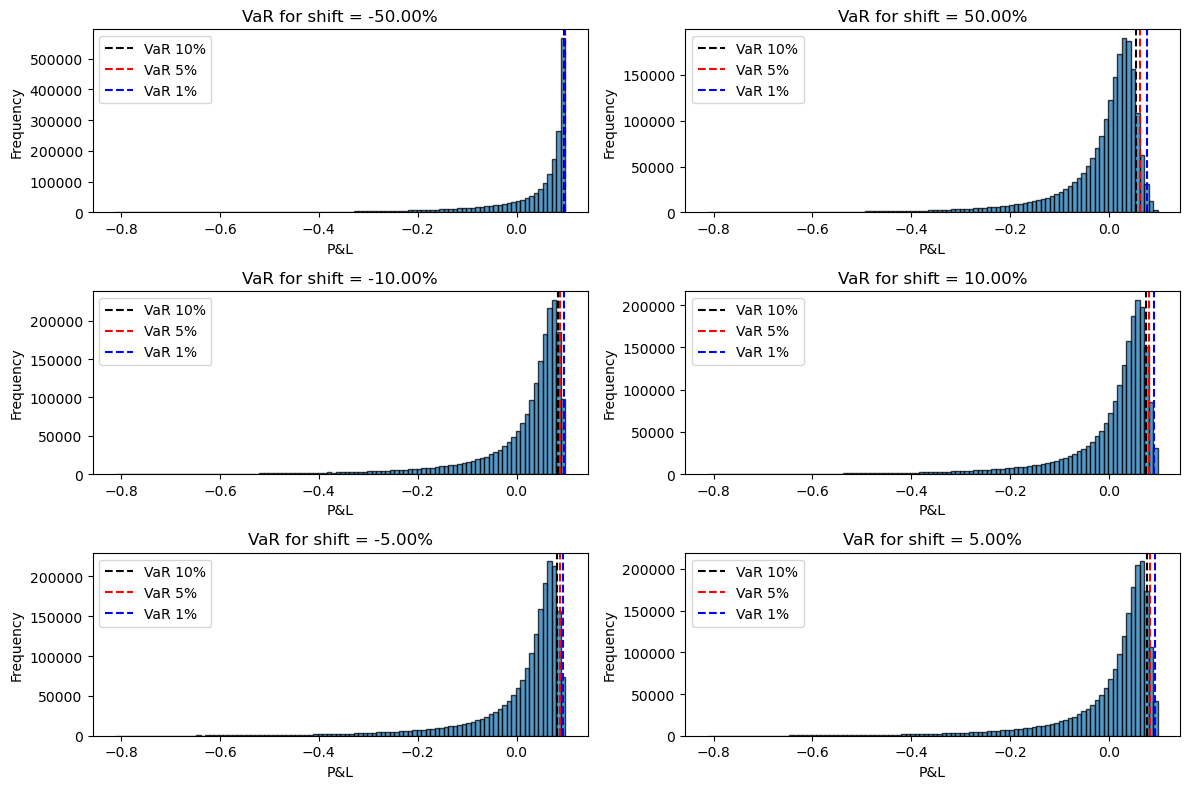

In [31]:
tM = 0.5
vol_shifts2=[-0.5, 0.5, -0.1, 0.1, -0.05, 0.05]

plt.figure(figsize=(12, 8))

# Extract stock prices at time tM (Nv, Ns)
S_tM = S[:, 126, :]  # Shape: (Nv, Ns)

for idx, delta in enumerate(vol_shifts2):
    sigma_adj = impl_vol * (1 + delta)

    # Vectorized Black-Scholes calculation for the entire S_tM array
    option_prices_tM_adj = black_scholes_put(S_tM, K, tM, r, q, sigma_adj)  # Vectorized

    # Compute adjusted P&L (Value at Risk)
    V_adj = heston_price_put - np.exp(-r * tM) * option_prices_tM_adj

    # Plot histogram for each volatility shift
    plt.subplot(3, 2, idx + 1)
    plt.hist(V_adj.flatten(), bins=100, edgecolor="black" ,alpha=0.75)
    plt.axvline(np.percentile(V_adj.flatten(), 90), color='black', linestyle='--', label='VaR 10%')
    plt.axvline(np.percentile(V_adj.flatten(), 95), color='red', linestyle='--', label='VaR 5%')
    plt.axvline(np.percentile(V_adj.flatten(), 99), color='blue', linestyle='--', label='VaR 1%')
    plt.title(f'VaR for shift = {delta:.2%}')
    plt.xlabel('P&L')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()
